In [12]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
import os

In [13]:
load_dotenv()


groq_api_key = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.5,
    groq_api_key=groq_api_key
)

In [ ]:
MAX_TOKENS = 450

In [ ]:
def call_model(state: MessagesState):
    
    #trim conversation history -last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [16]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [17]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

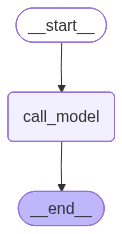

In [18]:
graph

In [19]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Mohit."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Mohit.


'Hello Mohit! 👋 How can I assist you today?'

In [20]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Mohit.
Hello Mohit! 👋 How can I assist you today?
Can you explain short term memory?


''

In [21]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 53
Hi, my name is Mohit.
Hello Mohit! 👋 How can I assist you today?
Can you explain short term memory?

What is my name?


'Your name is Mohit.'

In [22]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Mohit.
------------------------------------------------------------------------------------------------------------------------
Hello Mohit! 👋 How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------
What is my name?
------------------------------------------------------------------------------------------------------------------------
Your name is Mohit.
------------------------------------------------------------------------------------------------------------------------
